# Initialization

In [1]:
import os 
import torch
import sys
import random
from tqdm.auto import tqdm
from safetensors.torch import save_file
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
import argparse

# sys.path.append('.')
from esd.utils.sd_utils import esd_sd_call
StableDiffusionPipeline.__call__ = esd_sd_call

from collections import defaultdict
import numpy as np

def nested_list():
    return defaultdict(list)


/home/nessessence/anaconda3/envs/uul/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rng = np.random.RandomState(999)

# seed = random.randint(0, 2**15)
max_n_sample = 10000
random_seeds = rng.choice(range(2**15), size=max_n_sample, replace=True) # max [n_concept,n_seed]

print(random_seeds)

[30144 12636 13157 ...  9183 24006 17144]


In [3]:
def load_sd_models(basemodel_id="CompVis/stable-diffusion-v1-4", torch_dtype=torch.bfloat16, device='cuda:0'):
    
    base_unet = UNet2DConditionModel.from_pretrained(basemodel_id, subfolder="unet").to(device, torch_dtype)
    base_unet.requires_grad_(False)
    
    esd_unet = UNet2DConditionModel.from_pretrained(basemodel_id, subfolder="unet").to(device, torch_dtype)
    pipe = StableDiffusionPipeline.from_pretrained(basemodel_id, unet=base_unet, torch_dtype=torch_dtype, use_safetensors=True).to(device)
    
    return pipe, base_unet, esd_unet






def update_output_stats(noise_pred_erase, noise_pred_general, timestep,
                        erase_concept="erase", general_concept="general"):
    global output_stats

    # Flatten to vectors
    erase_flat = noise_pred_erase.flatten(start_dim=0).detach().cpu()
    general_flat = noise_pred_general.flatten(start_dim=0).detach().cpu()

    # Norms
    norm_erase = torch.norm(erase_flat).item()
    norm_general = torch.norm(general_flat).item()

    # Dot product
    dot_val = torch.dot(erase_flat, general_flat).item()

    # Cosine similarity
    cosine_val = dot_val / (norm_erase * norm_general + 1e-8)

    # Store results grouped by timestep under each key
    output_stats[f"raw_{erase_concept}"][timestep].append(erase_flat)
    output_stats[f"raw_{general_concept}"][timestep].append(general_flat)
    output_stats[f"norm_{erase_concept}"][timestep].append(norm_erase)
    output_stats[f"norm_{general_concept}"][timestep].append(norm_general)
    output_stats[f"dot_{erase_concept}.{general_concept}"][timestep].append(dot_val)
    output_stats[f"cosine_{erase_concept}.{general_concept}"][timestep].append(cosine_val)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def compute_means_and_ci(A, B=None, alpha=0.05):
    ## two-sided confidence intervals (alpha/2)
    """
    Compute means and confidence intervals for one or two groups.
    
    Args:
        A: Array of data for group A (required)
        B: Array of data for group B (optional, default=None)
        alpha: Significance level (default 0.05 for 95% CI)
    
    Returns:
        dict: Contains means, confidence intervals, margin of error, and other statistics
    """
    # Compute mean and CI for group A
    mean_A = np.mean(A)
    var_A = np.var(A, ddof=1)
    n_A = len(A)
    se_A = np.sqrt(var_A / n_A)
    
    # t-critical value for group A
    df_A = n_A - 1
    t_crit_A = stats.t.ppf(1 - alpha/2, df_A)
    margin_A = t_crit_A * se_A  # Margin of error
    ci_A = (mean_A - margin_A, mean_A + margin_A)
    
    result = {
        'mean_A': mean_A,
        'ci_A': ci_A,
        'margin_A': margin_A,  # Margin of error (t_crit * se)
        'se_A': se_A,
        'n_A': n_A,
        'df_A': df_A
    }
    
    # If group B is provided, compute additional statistics
    if B is not None:
        mean_B = np.mean(B)
        var_B = np.var(B, ddof=1)
        n_B = len(B)
        se_B = np.sqrt(var_B / n_B)
        
        # t-critical value for group B
        df_B = n_B - 1
        t_crit_B = stats.t.ppf(1 - alpha/2, df_B)
        margin_B = t_crit_B * se_B  # Margin of error
        ci_B = (mean_B - margin_B, mean_B + margin_B)
        
        # Difference statistics
        diff_mean = mean_A - mean_B
        se_diff = np.sqrt(var_A / n_A + var_B / n_B)
        
        # Degrees of freedom for difference (Welch-Satterthwaite)
        numerator = (var_A / n_A + var_B / n_B)**2
        denominator = ((var_A / n_A)**2 / (n_A - 1) + 
                       (var_B / n_B)**2 / (n_B - 1))
        df_diff = numerator / denominator
        
        t_crit_diff = stats.t.ppf(1 - alpha/2, df_diff)
        margin_diff = t_crit_diff * se_diff  # Margin of error for difference
        ci_diff = (diff_mean - margin_diff, diff_mean + margin_diff)
        
        # Add group B and difference statistics to result
        result.update({
            'mean_B': mean_B,
            'ci_B': ci_B,
            'margin_B': margin_B,  # Margin of error for B
            'se_B': se_B,
            'n_B': n_B,
            'df_B': df_B,
            'mean_diff': diff_mean,
            'ci_diff': ci_diff,
            'margin_diff': margin_diff,  # Margin of error for difference
            'se_diff': se_diff,
            'df_diff': df_diff
        })
    
    return result


def _to_int_timestep(t):
    try:
        return int(t.item())
    except Exception:
        return int(t)

def _series_from_output_stats(output_stats, key):
    """
    Returns sorted timesteps and lists of values per timestep for a given key.
    """
    if key not in output_stats:
        raise KeyError(f"Key '{key}' not found in output_stats")
    # normalize timestep keys to int and sort
    items = [(_to_int_timestep(t), output_stats[key][t]) for t in output_stats[key].keys()]
    items.sort(key=lambda x: x[0])
    timesteps = [t for t, _ in items]
    values_per_t = [np.array(v, dtype=float) for _, v in items]
    return timesteps, values_per_t

def plot_output_stats(output_stats, stat="cosine",
                      erase_concept="erase", general_concept="general",
                      alpha=0.05, figsize=(10, 6), plot_ci=True):
    """
    Plot mean ± CI over timesteps for:
      - stat in {'dot','cosine'}: one line for f'{stat}_{erase}.{general}'
      - stat == 'norm': two lines, f'norm_{erase}' and f'norm_{general}'
    Uses compute_means_and_ci(A, B=None, alpha) provided by the user.
    """
    assert stat in {"norm", "dot", "cosine", "minmax_inverse_cosine"}, \
        "stat must be one of {'norm','dot','cosine','minmax_inverse_cosine'}"
    plt.figure(figsize=figsize)
    if stat == "norm":
        key_e = f"norm_{erase_concept}"
        key_g = f"norm_{general_concept}"

        # erase
        ts_e, vals_list_e = _series_from_output_stats(output_stats, key_e)
        means_e, lo_e, hi_e = [], [], []
        for arr in vals_list_e:
            res = compute_means_and_ci(arr, alpha=alpha)
            means_e.append(res["mean_A"]); lo_e.append(res["ci_A"][0]); hi_e.append(res["ci_A"][1])

        # general
        ts_g, vals_list_g = _series_from_output_stats(output_stats, key_g)
        means_g, lo_g, hi_g = [], [], []
        for arr in vals_list_g:
            res = compute_means_and_ci(arr, alpha=alpha)
            means_g.append(res["mean_A"]); lo_g.append(res["ci_A"][0]); hi_g.append(res["ci_A"][1])

        # plot
        plt.plot(ts_e, means_e, label=f"‖{erase_concept}‖")
        if plot_ci:
            plt.fill_between(ts_e, lo_e, hi_e, alpha=0.2, linewidth=0)

        plt.plot(ts_g, means_g, label=f"‖{general_concept}‖")
        if plot_ci:
            plt.fill_between(ts_g, lo_g, hi_g, alpha=0.2, linewidth=0)

        ylabel = "Norm"

    else:
        key = f"{stat}_{erase_concept}.{general_concept}"
        ts, vals_list = _series_from_output_stats(output_stats, key)
        means, lo, hi = [], [], []
        for arr in vals_list:
            res = compute_means_and_ci(arr, alpha=alpha)
            means.append(res["mean_A"]); lo.append(res["ci_A"][0]); hi.append(res["ci_A"][1])

        plt.plot(ts, means, label=key.replace("_", " "))
        if plot_ci:
            plt.fill_between(ts, lo, hi, alpha=0.2, linewidth=0)

        if stat == "dot":
            ylabel = "Dot product"
        elif stat == "cosine":
            ylabel = "Cosine similarity"
        else:  # "minmax_inverse_cosine"
            ylabel = "Min–max inverse cosine (PDF weight)"

    plt.xlabel("Timestep")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} over timesteps")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def add_minmax_inverse_cosine(output_stats, erase_concept, general_concept, eps=1e-12):
    """
    Create a per-timestep probability (discrete PDF) from cosine similarities:
      - take mean cosine per timestep
      - min-max normalize to [0, 1]
      - invert -> 1 - normed  (so high cosine => low prob)
      - renormalize so they sum to 1 (valid PDF)
    Stores it back into output_stats under key:
        f"minmax_inverse_cosine_{erase}.{general}"
    Each timestep is stored as a list with >=2 identical values so that
    your compute_means_and_ci(ddof=1) won't crash on n==1.
    Returns (timesteps, probs) for convenience.
    """
    # 1) pull cosine series
    cos_key = f"cosine_{erase_concept}.{general_concept}"
    if cos_key not in output_stats:
        raise KeyError(f"Missing key in output_stats: {cos_key}")

    # sort timesteps, collect per-timestep arrays
    items = []
    for t, vals in output_stats[cos_key].items():
        try:
            ti = int(t.item())
        except Exception:
            ti = int(t)
        items.append((ti, np.asarray(vals, dtype=float)))
    items.sort(key=lambda x: x[0])

    timesteps = [t for t, _ in items]
    per_t_arrays = [arr for _, arr in items]

    # 2) mean cosine per timestep
    means = np.array([a.mean() for a in per_t_arrays], dtype=float)

    # 3) min-max normalize to [0,1]
    mn, mx = means.min(), means.max()
    rng = mx - mn
    if rng < eps:
        # nearly constant; treat them all equal
        normed = np.zeros_like(means)
    else:
        normed = (means - mn) / (rng + eps)

    # 4) invert and make a PDF
    inv = 1.0 - normed
    s = inv.sum()
    if s < eps:
        # if everything collapsed to 0, use uniform
        probs = np.ones_like(inv) / len(inv)
    else:
        probs = inv / s

    # 5) write back into output_stats with a safe list length (>=2)
    new_key = f"minmax_inverse_cosine_{erase_concept}.{general_concept}"
    series = {}
    for (t, arr), p in zip(items, probs):
        # keep list length >=2 (and match original count when available)
        k = max(2, len(arr))
        series[t] = [float(p)] * k
    output_stats[new_key] = series

    return timesteps, probs


In [5]:
def mse(a: torch.Tensor, b: torch.Tensor) -> float:
    """
    Compute mean squared error between two tensors.
    Returns 0.0 if they are exactly identical.
    """
    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")
    return torch.mean((a - b) ** 2).item()

# Experiment

In [4]:
device = 'cuda:1'
torch_dtype = torch.bfloat16

num_inference_steps = 50
height=width=512
batchsize = 50
guidance_scale = 3.0
timestep_cond = None

seed = random.randint(0, 2**15)

erase_concept = "a photo of Barrack obama"
general_concept = "a photo of person"
# pipe, base_unet, esd_unet = load_sd_models(basemodel_id="CompVis/stable-diffusion-v1-4", torch_dtype=torch_dtype, device=device)


# pipe.set_progress_bar_config(disable=True)
# pipe.scheduler.set_timesteps(num_inference_steps)


In [4]:
with torch.no_grad():
    
        erase_embeds, null_embeds = pipe.encode_prompt(prompt=erase_concept,
                                                       device=device,
                                                       num_images_per_prompt=batchsize,
                                                       do_classifier_free_guidance=True,
                                                       negative_prompt='')
                                                 
        erase_embeds = erase_embeds.to(device)
        null_embeds = null_embeds.to(device)
        
        general_embeds, _ = pipe.encode_prompt(prompt=general_concept,
                                                device=device,
                                                num_images_per_prompt=batchsize,
                                                do_classifier_free_guidance=True,
                                                negative_prompt='')
        base_embeds = general_embeds.to(device)
        

In [ ]:

# declare once outside the function
output_stats = defaultdict(lambda: defaultdict(list))
n_samples = 50

total_n =  n_samples * num_inference_steps
with tqdm(total=total_n, desc="Processing") as pbar:
    with torch.no_grad():
        for t_inferstep in range(0, num_inference_steps-1):
            t = pipe.scheduler.timesteps[t_inferstep]
            for _ in range(n_samples):
                # random t

                # print(f"t: {t}, t_inferstep: {t_inferstep}")

                # sample z_t with Pg ("person")
                z_t = pipe(general_concept, 
                        num_images_per_prompt=batchsize, num_inference_steps=num_inference_steps, guidance_scale=guidance_scale, 
                        run_till_timestep=t_inferstep, generator=torch.Generator().manual_seed(seed), output_type='latent', height=height, width=width).images

                # 
                noise_pred_erase = pipe.unet(
                    z_t,
                    t,
                    encoder_hidden_states=erase_embeds,
                    timestep_cond=timestep_cond,
                    cross_attention_kwargs=None,
                    added_cond_kwargs=None,
                    return_dict=False,
                )[0][0]



                noise_pred_general = pipe.unet(
                    z_t,
                    t,
                    encoder_hidden_states=general_embeds,
                    timestep_cond=timestep_cond,
                    cross_attention_kwargs=None,
                    added_cond_kwargs=None,
                    return_dict=False,
                )[0][0]
                
                # print(noise_pred_erase.shape, noise_pred_general.shape) # [4, 128, 128], [4, 128, 128]

                update_output_stats(noise_pred_erase, noise_pred_general,timestep = t, erase_concept=erase_concept, general_concept=general_concept)

                # print(output_stats)
                
                pbar.update(1)
    # print(z_t.shape) # [1, 4, 64, 64] for 512x512 :::  [1, 4, 128, 128]

Processing:   2%|█▋                                                                                      | 236/12500 [05:17<4:35:12,  1.35s/it]


KeyboardInterrupt: 

# Analysis

/tmp/ipykernel_3671246/933585564.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  output_stats = torch.load(f'data_root/cache/compositional_latents/{general_concept}.{era

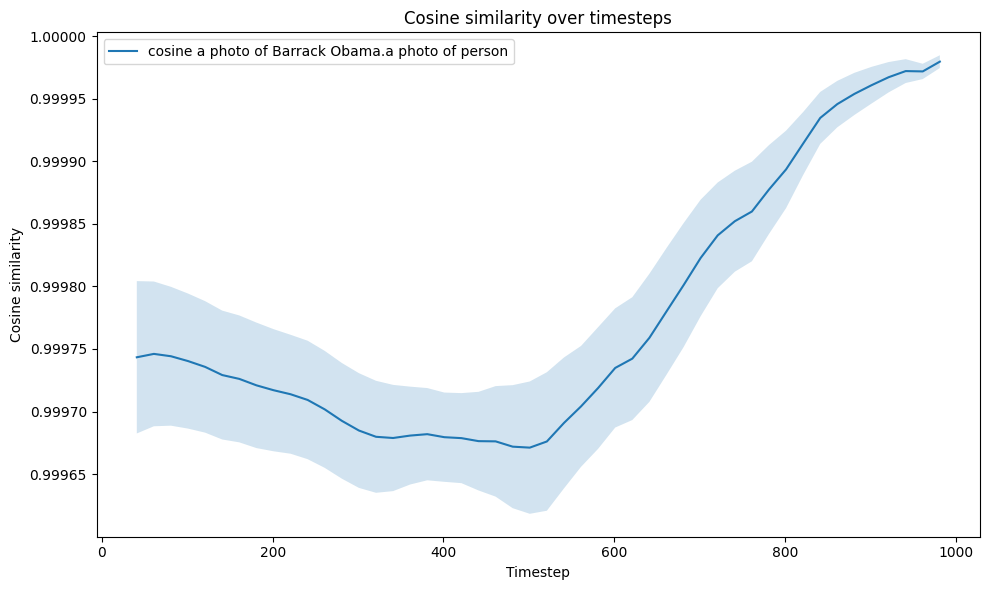

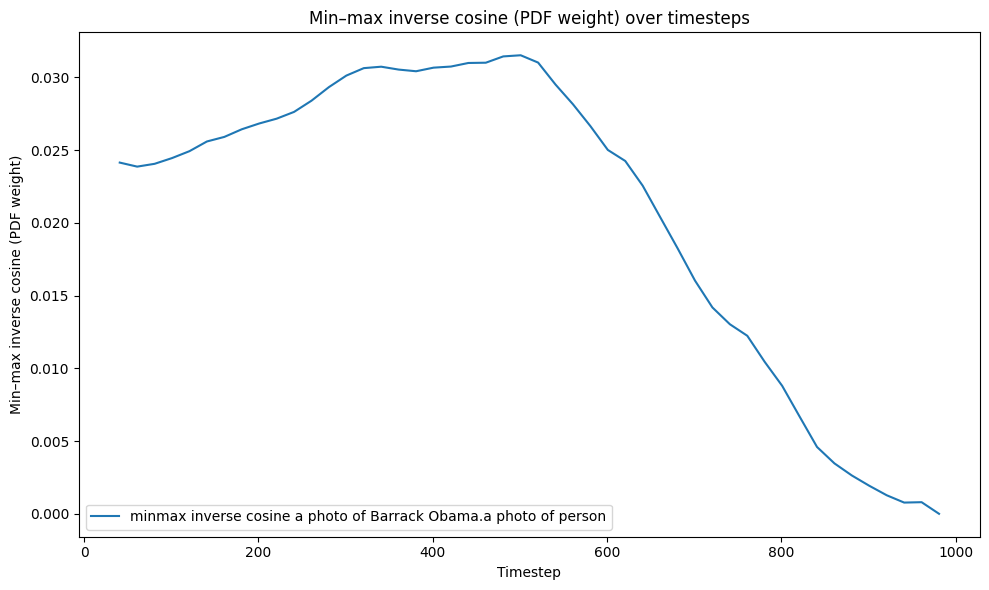

In [12]:
general_concept = "a photo of person"
erase_concept = "a photo of Barrack Obama"
output_stats = torch.load(f'data_root/cache/compositional_latents/{general_concept}.{erase_concept}_zt_nT50.n50.bs10.seed999_{general_concept}.pt')

ts, probs = add_minmax_inverse_cosine(output_stats, erase_concept, general_concept)
plot_output_stats(output_stats, stat="cosine", erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
plot_output_stats(output_stats, stat="minmax_inverse_cosine",
                  erase_concept=erase_concept, general_concept=general_concept)


/tmp/ipykernel_3671246/3688757640.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  output_stats = torch.load(f'data_root/cache/compositional_latents/{general_concept}.{er

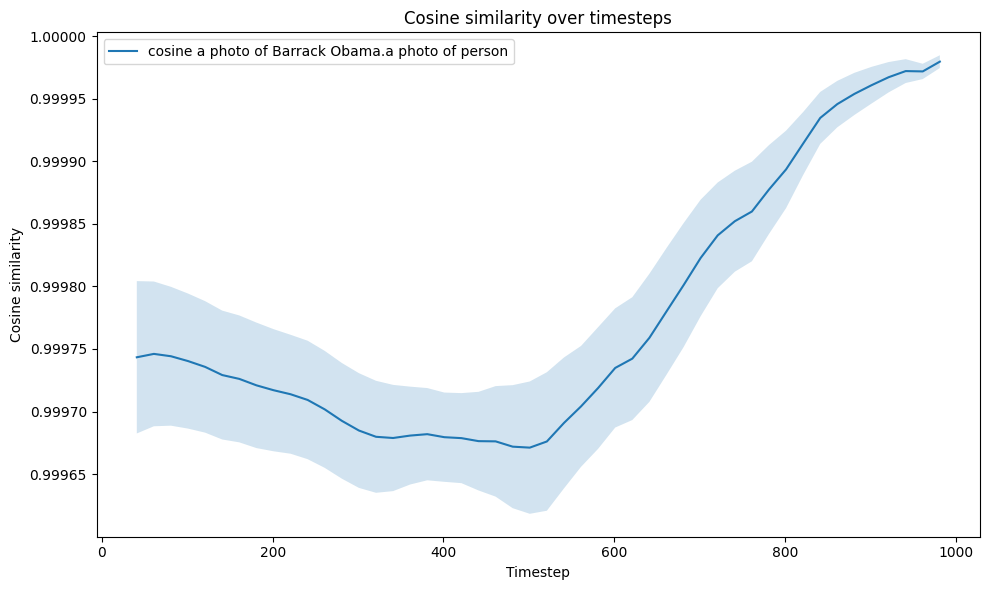

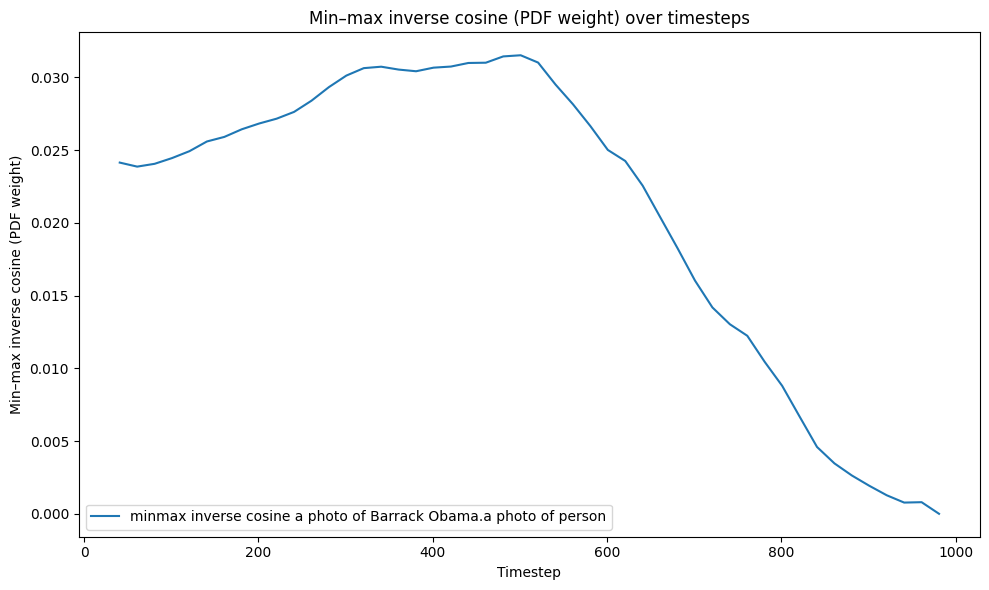

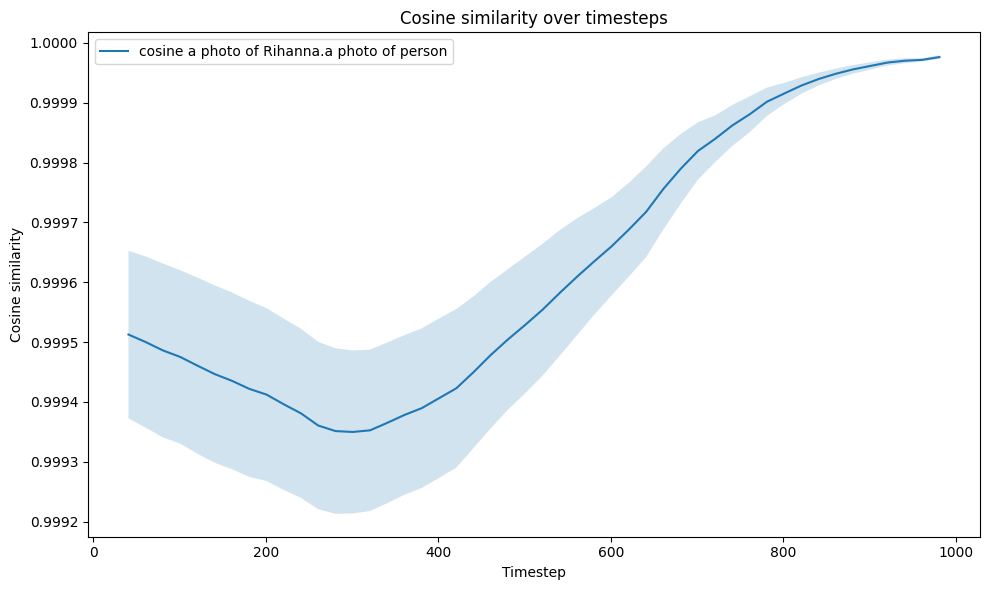

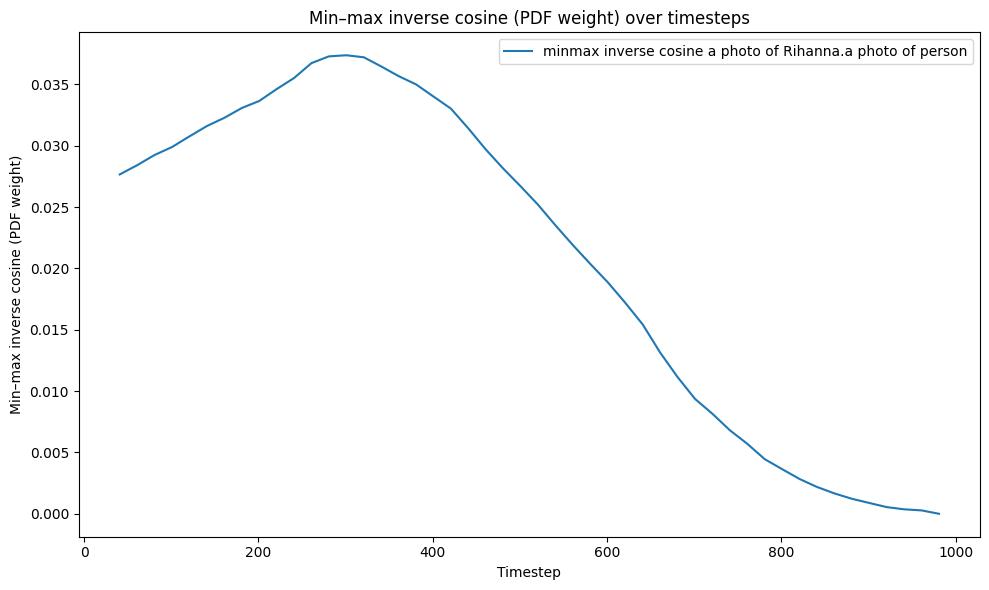

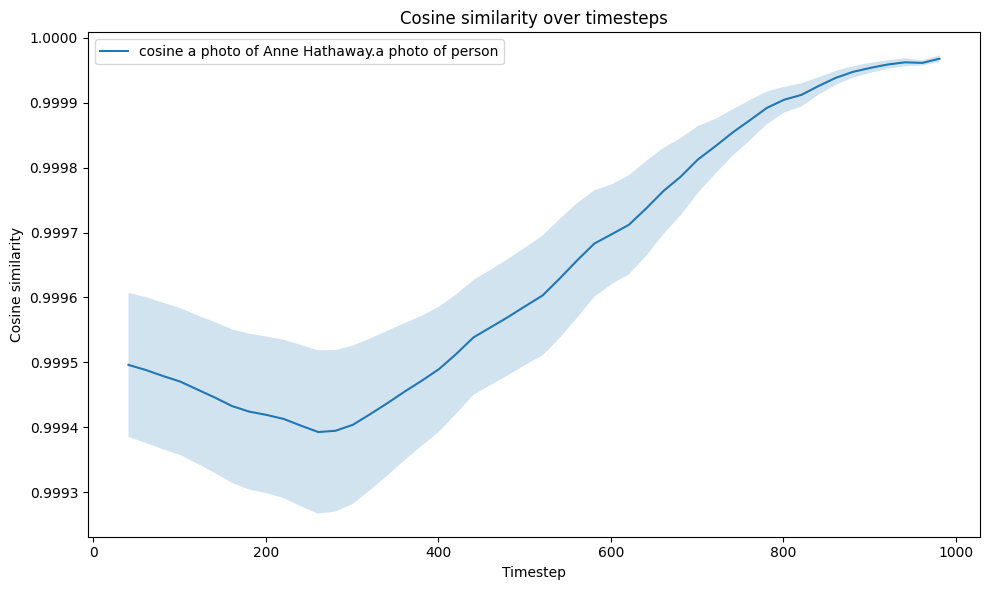

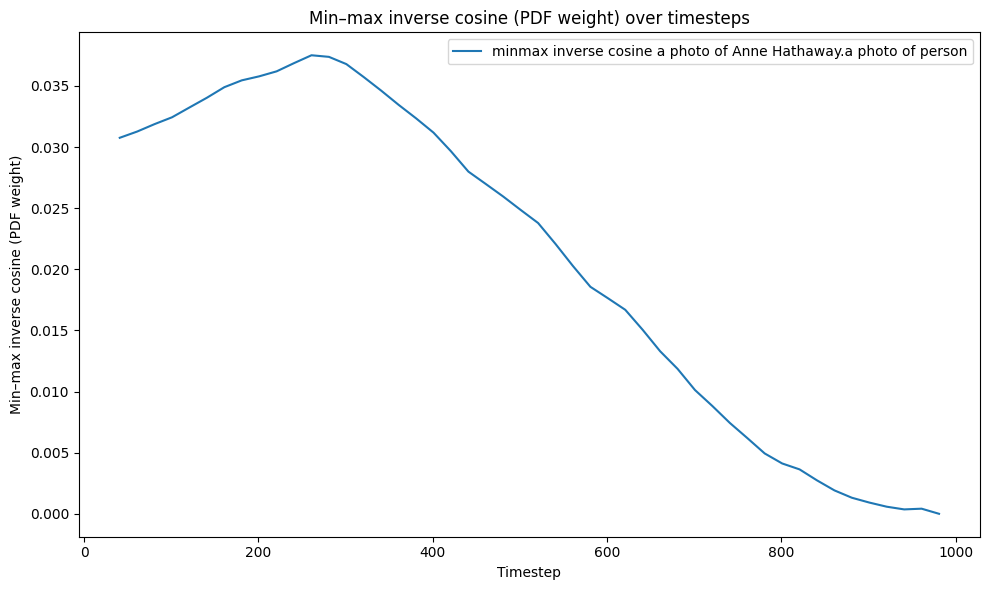

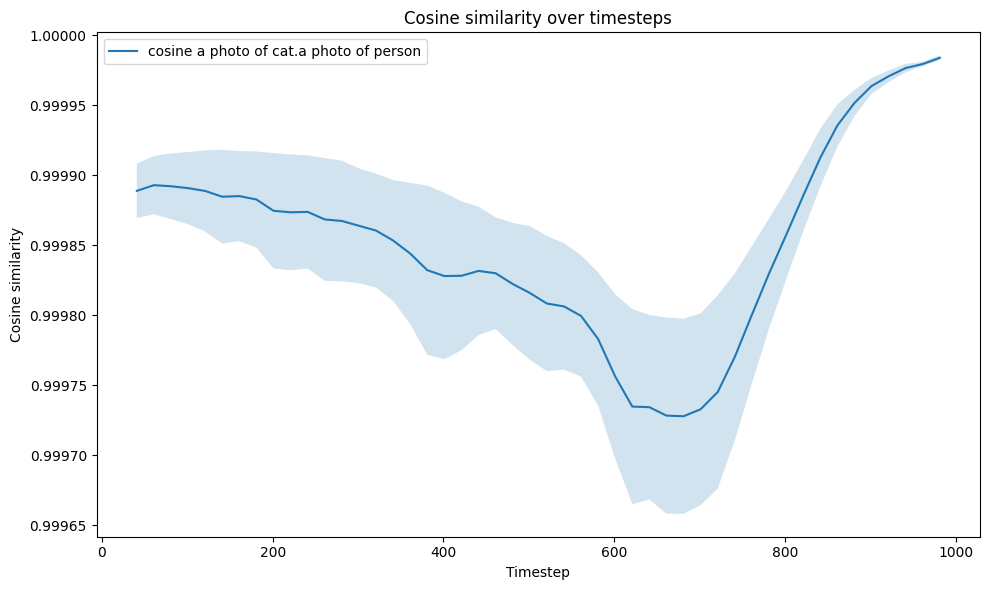

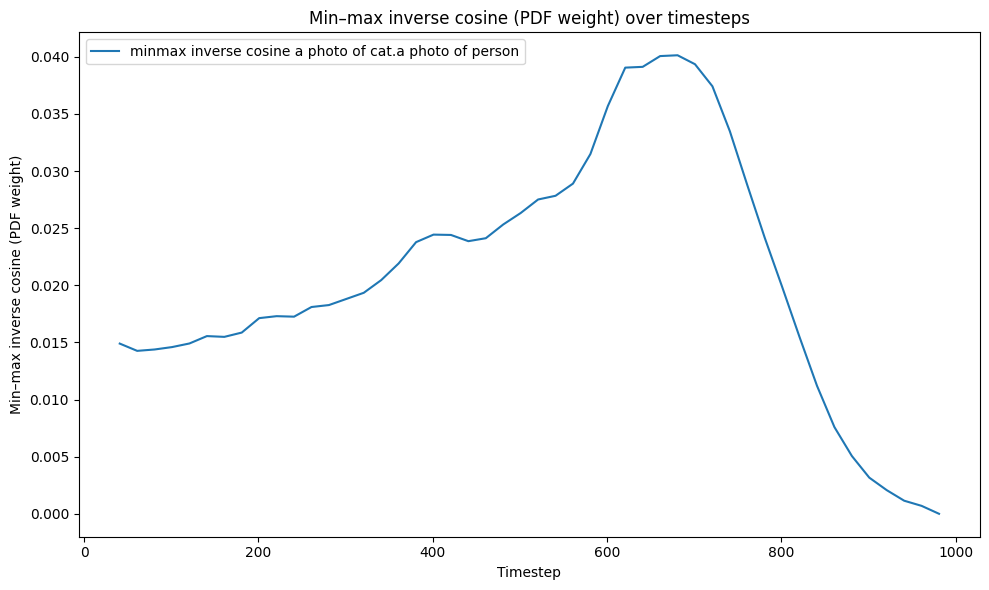

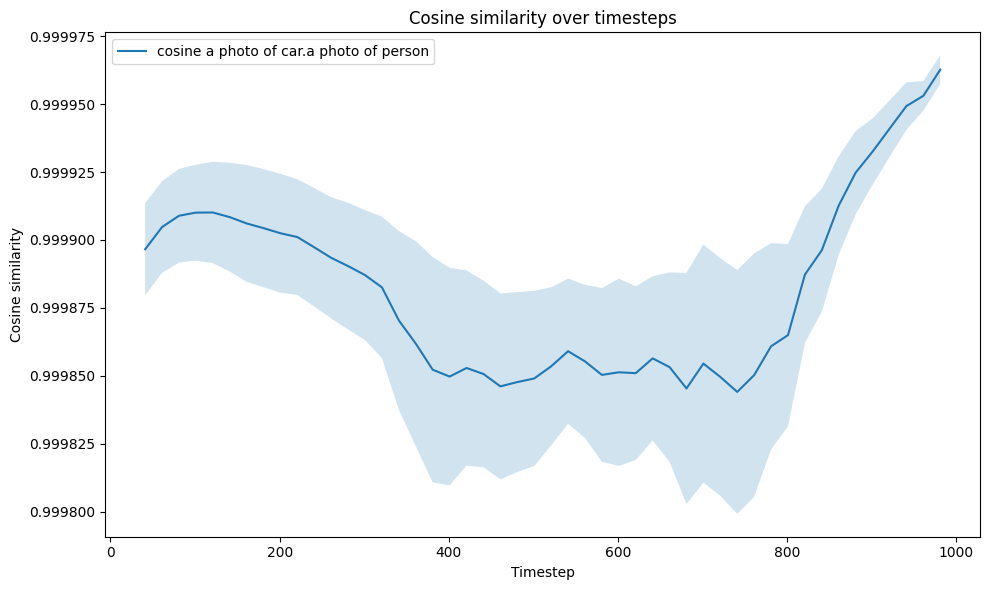

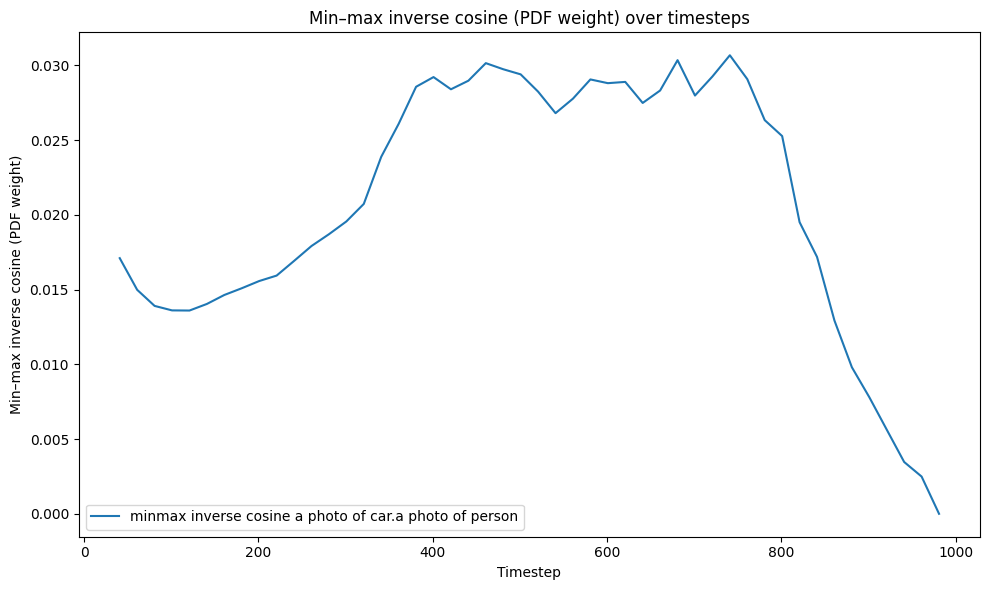

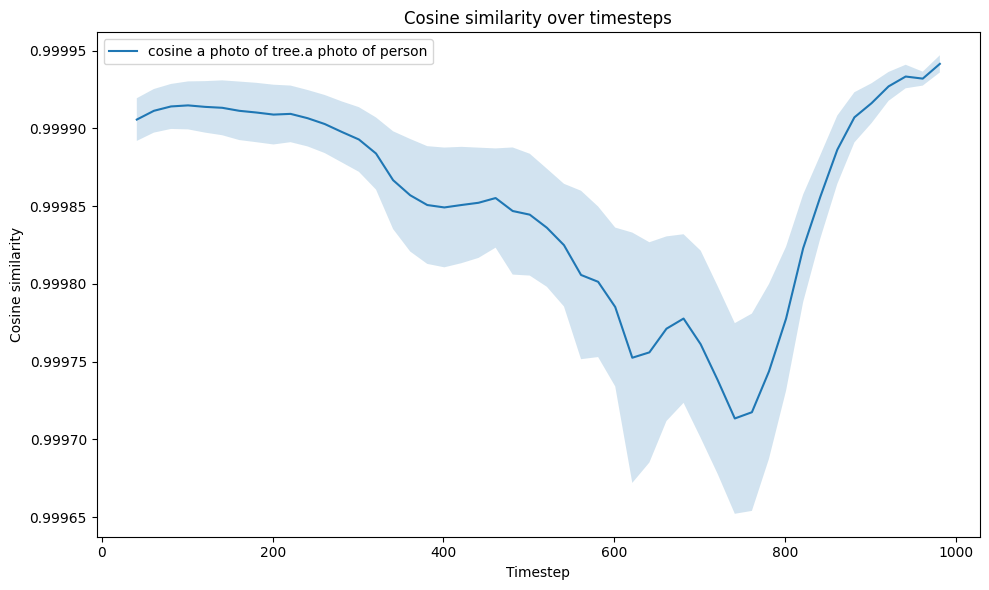

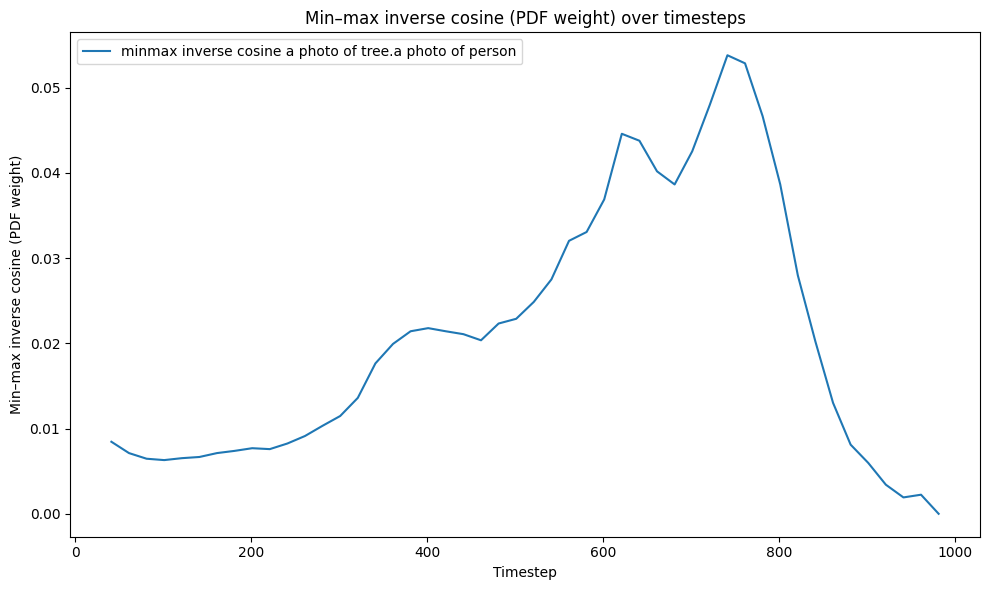

In [13]:
general_concept = "a photo of person"

for erase_concept in ['a photo of Barrack Obama','a photo of Rihanna', "a photo of Anne Hathaway",  "a photo of cat", "a photo of car", "a photo of tree"]:

    output_stats = torch.load(f'data_root/cache/compositional_latents/{general_concept}.{erase_concept}_zt_nT50.n50.bs10.seed999_{general_concept}.pt')
    ts, probs = add_minmax_inverse_cosine(output_stats, erase_concept, general_concept)

                  
    # plot_output_stats(output_stats, stat="norm",   erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
    # plot_output_stats(output_stats, stat="dot",    erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
    plot_output_stats(output_stats, stat="cosine", erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
    plot_output_stats(output_stats, stat="minmax_inverse_cosine",
                  erase_concept=erase_concept, general_concept=general_concept)


In [ ]:
general_concept = "a photo of person"
erase_concept = "a photo of Barrack Obama"
output_stats_obama = torch.load(f'data_root/cache/compositional_latents/{general_concept}.{erase_concept}_zt_nT50.n50.bs10.seed999_{general_concept}.pt')


general_concept = "a photo of person"
erase_concept = "a photo of Rihanna"
output_stats_rihanna = torch.load(f'data_root/cache/compositional_latents/{general_concept}.{erase_concept}_zt_nT50.n50.bs10.seed999_{general_concept}.pt')


/tmp/ipykernel_3671246/746218934.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  output_stats_obama = torch.load(f'data_root/cache/compositional_latents/{general_concept

KeyboardInterrupt: 

/tmp/ipykernel_3581727/3615006116.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  output_stats = torch.load('data_root/cache/compositional_latents/a photo of person.a ph

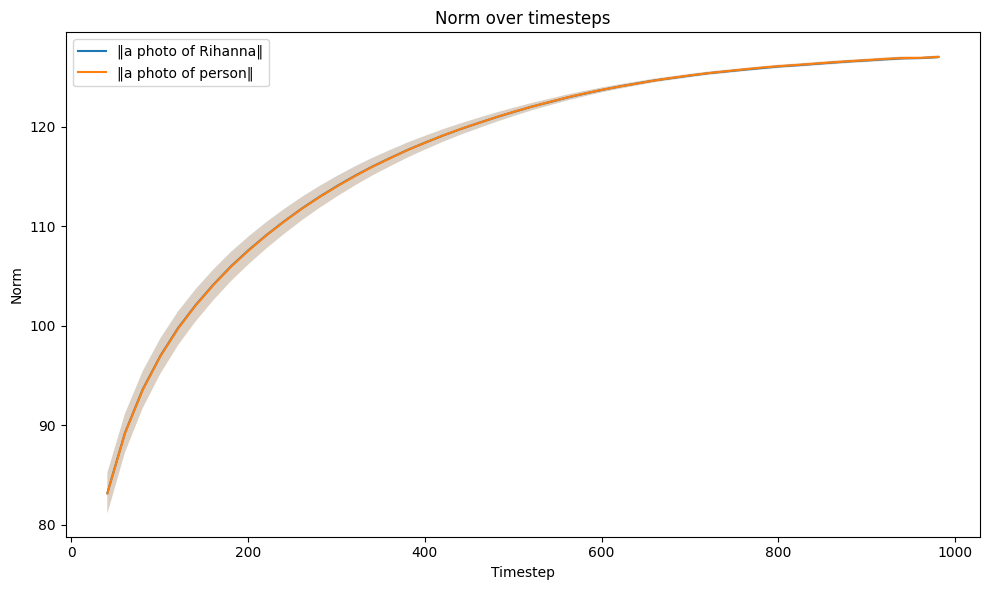

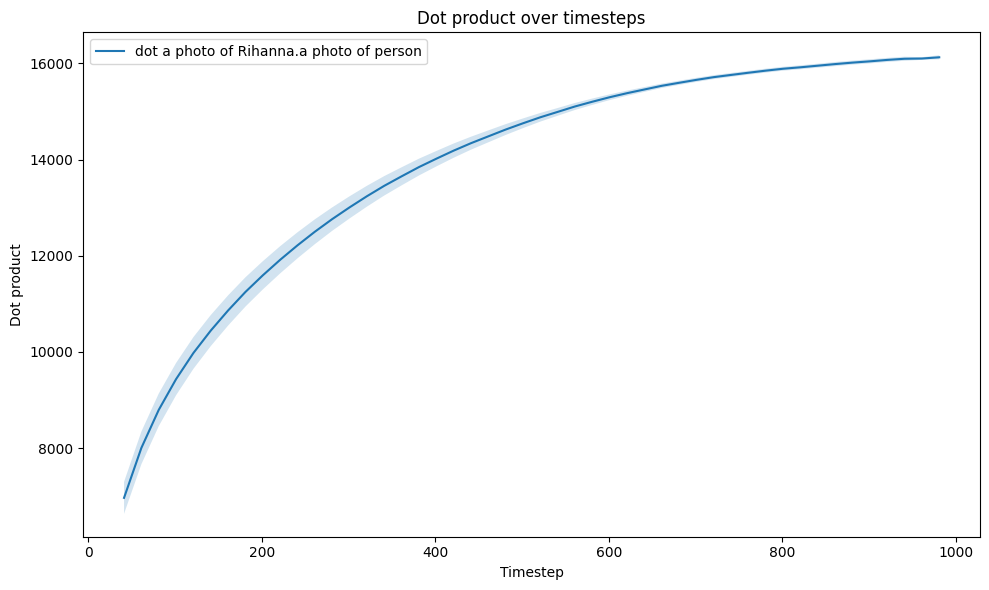

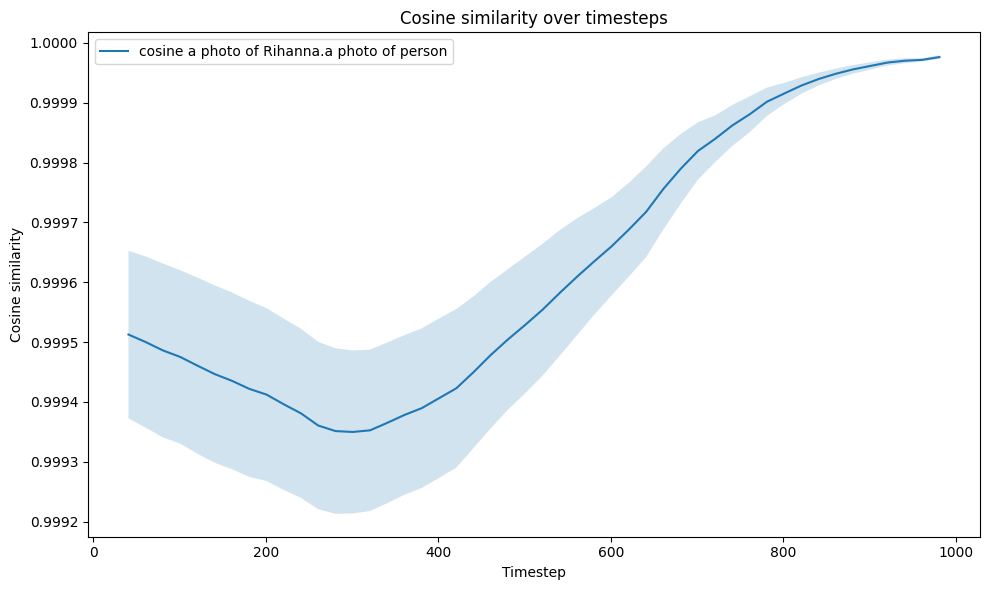

In [28]:
erase_concept = "a photo of Rihanna"
general_concept = "a photo of person"
output_stats = torch.load('data_root/cache/compositional_latents/a photo of person.a photo of Rihanna_zt_nT50.n50.bs10.seed999_a photo of person.pt')


plot_output_stats(output_stats, stat="norm",   erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
plot_output_stats(output_stats, stat="dot",    erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
plot_output_stats(output_stats, stat="cosine", erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)


/tmp/ipykernel_3581727/722601986.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  output_stats = torch.load('data_root/cache/compositional_latents/a photo of person.a pho

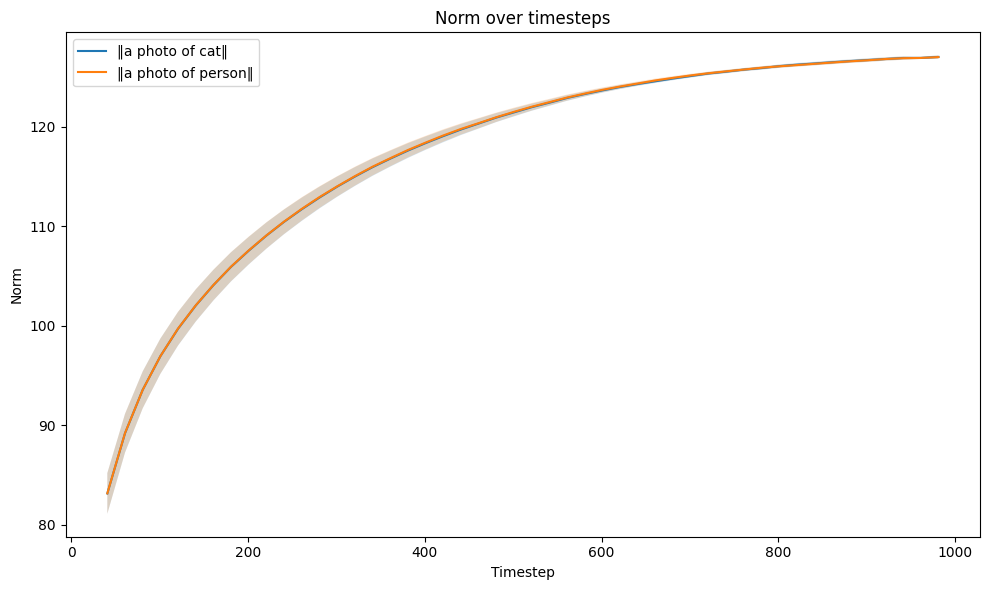

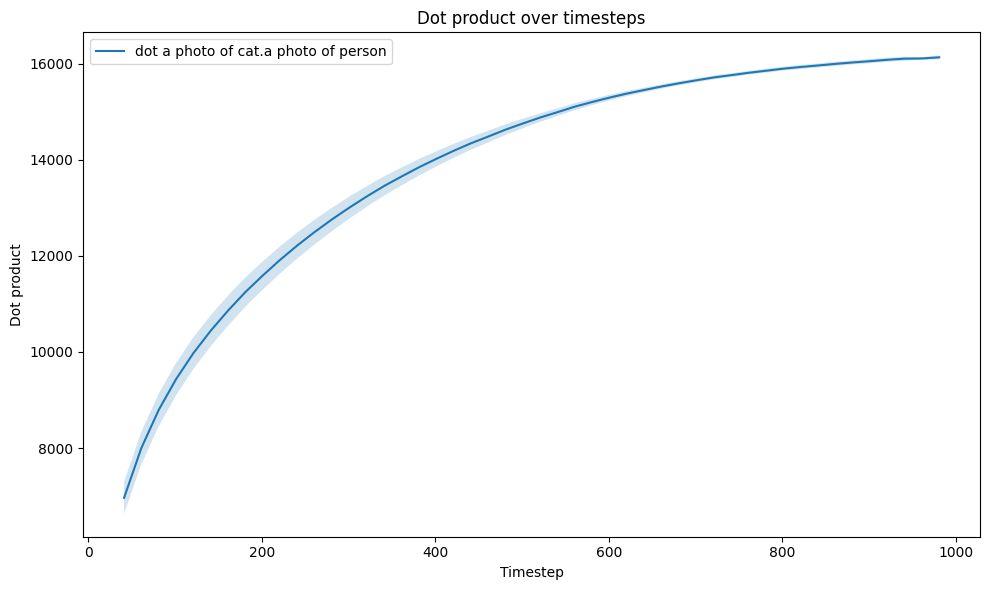

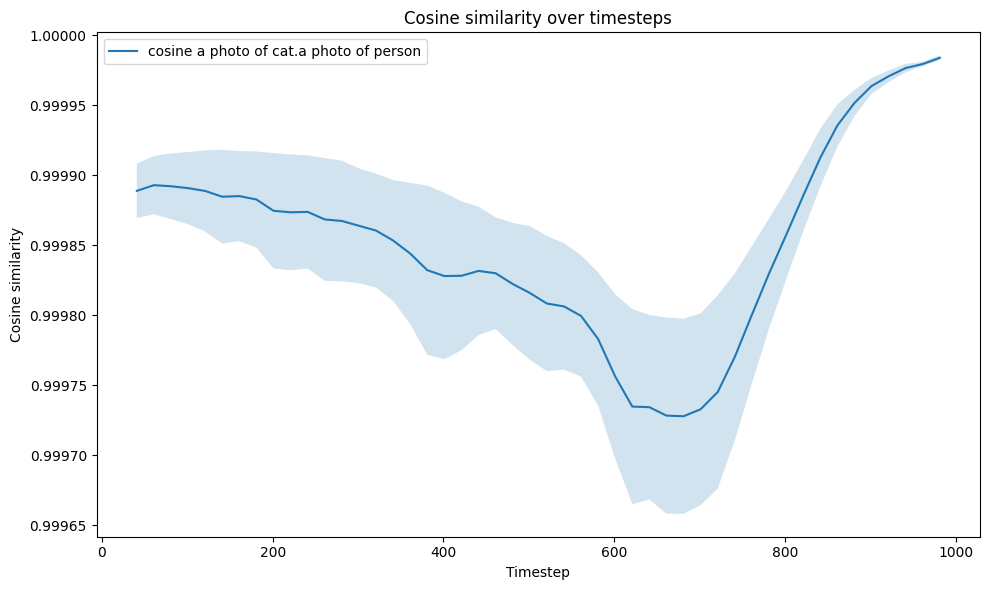

In [24]:
erase_concept = "a photo of cat"
general_concept = "a photo of person"
output_stats = torch.load('data_root/cache/compositional_latents/a photo of person.a photo of cat_zt_nT50.n50.bs10.seed999_a photo of person.pt')


plot_output_stats(output_stats, stat="norm",   erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
plot_output_stats(output_stats, stat="dot",    erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
plot_output_stats(output_stats, stat="cosine", erase_concept=erase_concept, general_concept=general_concept, alpha=0.05)
